In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns

In [5]:
np.random.seed(0)
lesson_series = np.round(np.random.random(size = 1000)**2 * 100, 2)
lesson_series[0:10] # check the first ten values.  Are they mostly on the small side?

array([30.12, 51.15, 36.33, 29.69, 17.95, 41.72, 19.15, 79.53, 92.86,
       14.7 ])

<Axes: ylabel='Count'>

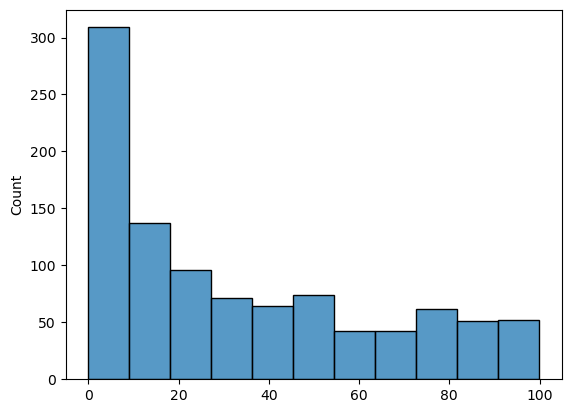

In [6]:
sns.histplot(lesson_series)

In [7]:
np.histogram(lesson_series, bins = 11)[0]

array([309, 137,  96,  71,  64,  74,  42,  42,  62,  51,  52])

### Why [0] vs np.histogram(lesson_series, bins=11)
**np.histogram() returns a tuple with TWO elements:**
 1.  [0] - The histogram counts (frequency of values in each bin)
 2.  [1] - The bin edges (boundaries of each bin)


In [8]:
lesson_series_3 = np.round(np.random.random(size = 100)**4 * 100, 2)

### This expression generates 100 random numbers with a heavily right-skewed distribution (most values near 0, few large values). Here's the breakdown:
**Step-by-step:**
- np.random.random(size=100)
- Generates 100 random numbers uniformly distributed between 0 and 1
- Example: [0.548, 0.715, 0.603, ...]
**4 (raise to 4th power)
- Takes each number to the 4th power
- This heavily skews the distribution toward 0
- Example: 0.5**4 = 0.0625, 0.9**4 = 0.6561
- Since all values are between 0-1, raising to 4th power makes small values much smaller
* 100 (multiply by 100)
- Scales the range from [0, 1] to [0, 100]
- Example: 0.0625 * 100 = 6.25
- np.round(..., 2) (round to 2 decimals)
- Rounds each value to 2 decimal places
- Example: 6.253847 → 6.25

In [10]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 10000
data = np.random.normal(size = num_data) + 6
df = pd.DataFrame(data.T, columns = ["data"])

histnums = np.histogram(df["data"])
histcounts = histnums[0]
histmins = histnums[1][0:-1]
histmaxes = histnums[1][1:]

pd.DataFrame(np.array([histcounts, histmins, histmaxes]).T, columns = ["count", "minval", "maxval"])

,count,minval,maxval
0,10.0,2.259899,3.014075
1,110.0,3.014075,3.768252
2,579.0,3.768252,4.522428
3,1710.0,4.522428,5.276604
4,2833.0,5.276604,6.030780
5,2688.0,6.030780,6.784956
6,1479.0,6.784956,7.539132
7,487.0,7.539132,8.293308
8,97.0,8.293308,9.047484
9,7.0,9.047484,9.801660


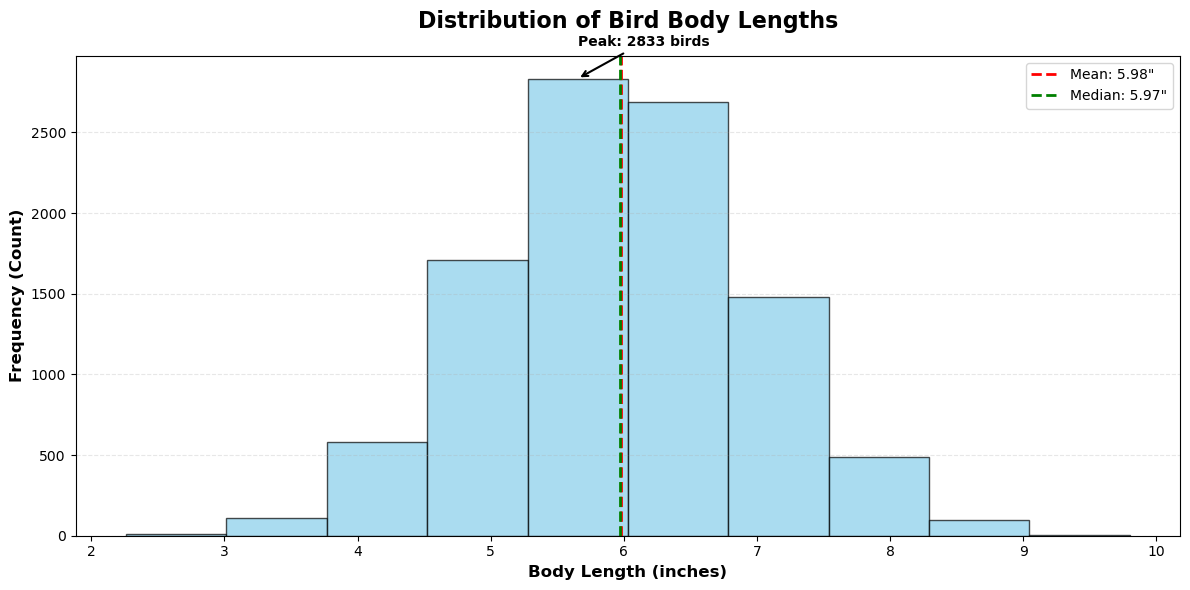

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create an enhanced histogram
plt.figure(figsize=(12, 6))

# Plot histogram with improvements
plt.hist(df['data'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)

# Add title and labels
plt.title('Distribution of Bird Body Lengths', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Body Length (inches)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (Count)', fontsize=12, fontweight='bold')

# Add mean and median lines
mean_val = df['data'].mean()
median_val = df['data'].median()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}"')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}"')

# Add grid for easier reading
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend
plt.legend(fontsize=10)

# Add annotations for the peak
counts, bins = np.histogram(df['data'], bins=10)
max_count_idx = counts.argmax()
peak_bin = (bins[max_count_idx] + bins[max_count_idx + 1]) / 2
plt.annotate(f'Peak: {counts.max()} birds', 
             xy=(peak_bin, counts.max()), 
             xytext=(peak_bin, counts.max() + 200),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Create enhanced table with additional columns
histnums = np.histogram(df["data"], bins=10)
histcounts = histnums[0]
histmins = histnums[1][0:-1]
histmaxes = histnums[1][1:]

# Calculate additional columns
total_count = histcounts.sum()
percentages = (histcounts / total_count) * 100
ranges = histmaxes - histmins
bin_centers = (histmins + histmaxes) / 2

# Create enhanced DataFrame
enhanced_table = pd.DataFrame({
    'Bin': range(1, len(histcounts) + 1),
    'Count': histcounts.astype(int),
    'Percentage': percentages,
    'Min Length (in)': histmins,
    'Max Length (in)': histmaxes,
    'Bin Width (in)': ranges,
    'Bin Center (in)': bin_centers
})

# Format the display
styled_table = enhanced_table.style\
    .format({
        'Count': '{:,}',
        'Percentage': '{:.2f}%',
        'Min Length (in)': '{:.2f}',
        'Max Length (in)': '{:.2f}',
        'Bin Width (in)': '{:.2f}',
        'Bin Center (in)': '{:.2f}'
    })\
    .background_gradient(subset=['Count'], cmap='YlOrRd')\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), 
                                      ('color', 'white'), 
                                      ('font-weight', 'bold'),
                                      ('text-align', 'center')]}
    ])

display(styled_table)

,Bin,Count,Percentage,Min Length (in),Max Length (in),Bin Width (in),Bin Center (in)
0,1,10,0.10%,2.26,3.01,0.75,2.64
1,2,110,1.10%,3.01,3.77,0.75,3.39
2,3,579,5.79%,3.77,4.52,0.75,4.15
3,4,"1,710",17.10%,4.52,5.28,0.75,4.90
4,5,"2,833",28.33%,5.28,6.03,0.75,5.65
5,6,"2,688",26.88%,6.03,6.78,0.75,6.41
6,7,"1,479",14.79%,6.78,7.54,0.75,7.16
7,8,487,4.87%,7.54,8.29,0.75,7.92
8,9,97,0.97%,8.29,9.05,0.75,8.67
9,10,7,0.07%,9.05,9.80,0.75,9.42


In [13]:
# Simpler version with clear formatting
enhanced_table = pd.DataFrame({
    'Bin': range(1, len(histcounts) + 1),
    'Count': histcounts.astype(int),
    'Percentage (%)': np.round(percentages, 2),
    'Min (in)': np.round(histmins, 2),
    'Max (in)': np.round(histmaxes, 2),
    'Range (in)': np.round(ranges, 2)
})

# Add a total row
total_row = pd.DataFrame({
    'Bin': ['Total'],
    'Count': [enhanced_table['Count'].sum()],
    'Percentage (%)': [enhanced_table['Percentage (%)'].sum()],
    'Min (in)': ['-'],
    'Max (in)': ['-'],
    'Range (in)': ['-']
})

enhanced_table = pd.concat([enhanced_table, total_row], ignore_index=True)
enhanced_table

,Bin,Count,Percentage (%),Min (in),Max (in),Range (in)
0,1,10,0.10,2.26,3.01,0.75
1,2,110,1.10,3.01,3.77,0.75
2,3,579,5.79,3.77,4.52,0.75
3,4,1710,17.10,4.52,5.28,0.75
4,5,2833,28.33,5.28,6.03,0.75
5,6,2688,26.88,6.03,6.78,0.75
6,7,1479,14.79,6.78,7.54,0.75
7,8,487,4.87,7.54,8.29,0.75
8,9,97,0.97,8.29,9.05,0.75
9,10,7,0.07,9.05,9.8,0.75


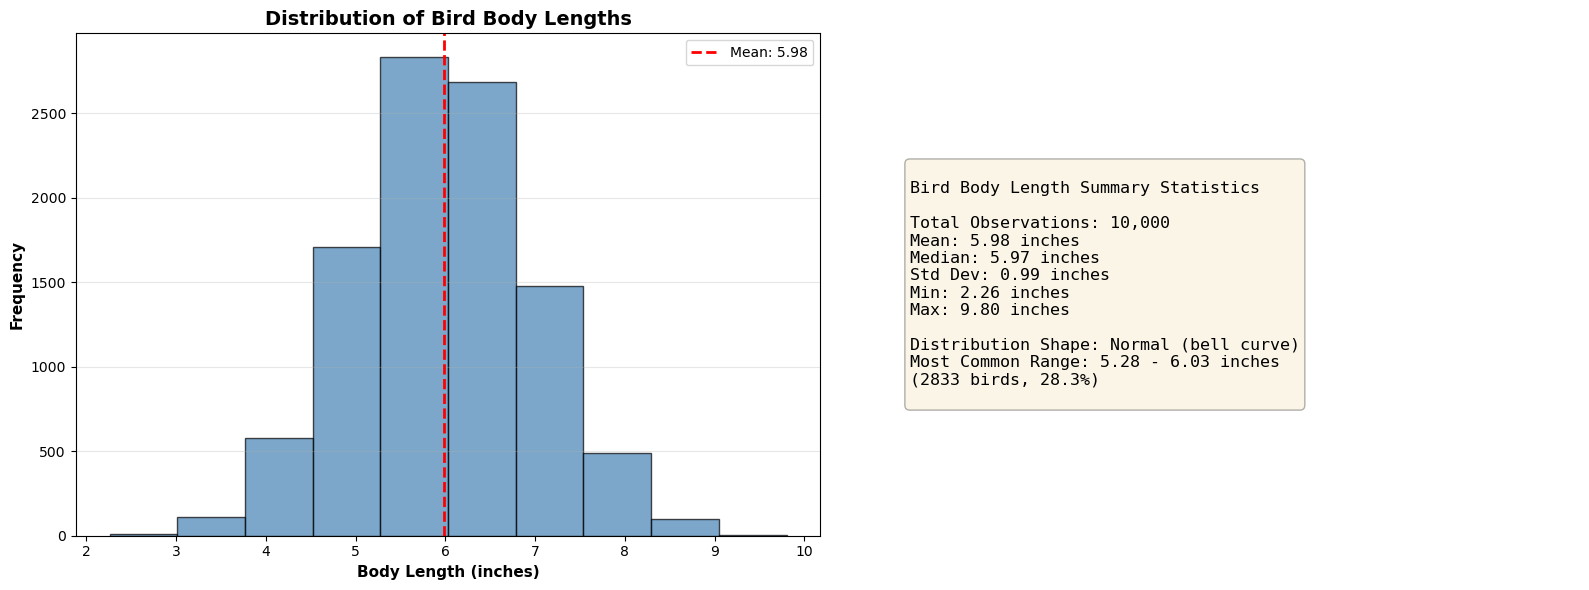

In [14]:
# Create a figure with both histogram and table
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Enhanced histogram
ax1.hist(df['data'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_title('Distribution of Bird Body Lengths', fontsize=14, fontweight='bold')
ax1.set_xlabel('Body Length (inches)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.axvline(df['data'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["data"].mean():.2f}')
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

# Right: Summary statistics as text
ax2.axis('off')
summary_text = f"""
Bird Body Length Summary Statistics

Total Observations: {len(df):,}
Mean: {df['data'].mean():.2f} inches
Median: {df['data'].median():.2f} inches
Std Dev: {df['data'].std():.2f} inches
Min: {df['data'].min():.2f} inches
Max: {df['data'].max():.2f} inches

Distribution Shape: Normal (bell curve)
Most Common Range: {histmins[histcounts.argmax()]:.2f} - {histmaxes[histcounts.argmax()]:.2f} inches
({histcounts.max()} birds, {(histcounts.max()/len(df)*100):.1f}%)
"""
ax2.text(0.1, 0.5, summary_text, fontsize=12, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

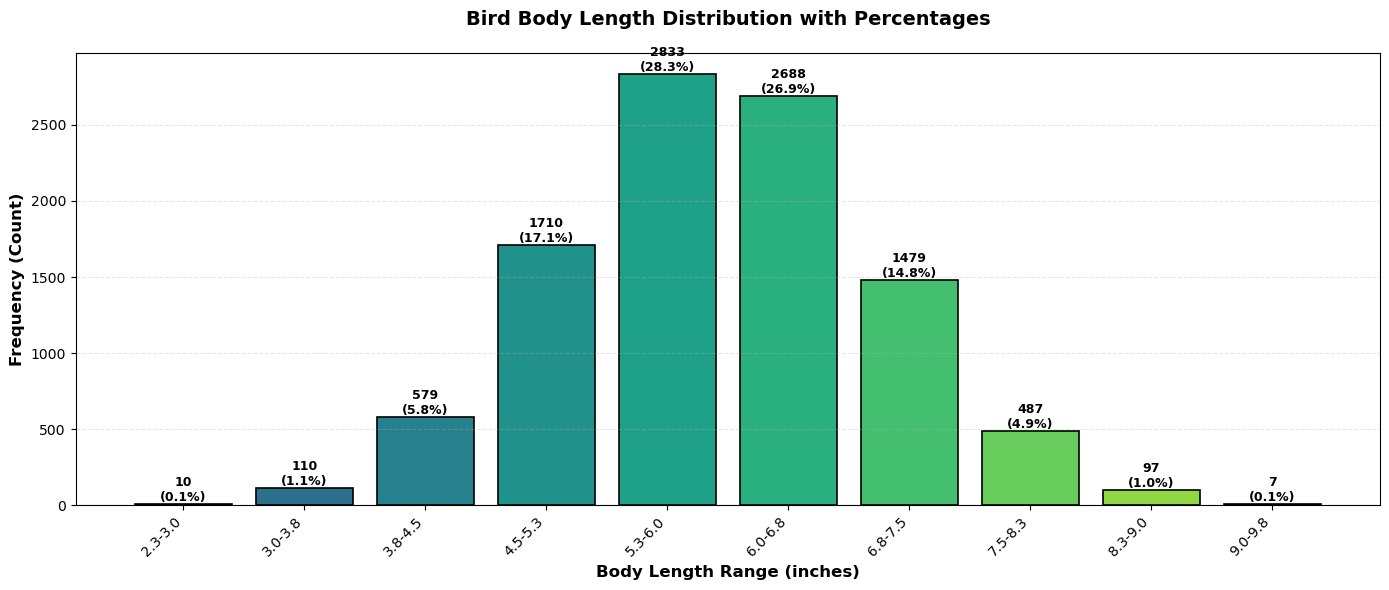

In [15]:
# Create a colorful bar chart with labels
fig, ax = plt.subplots(figsize=(14, 6))

# Create color gradient
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(histcounts)))

# Create bar chart
bin_labels = [f'{histmins[i]:.1f}-{histmaxes[i]:.1f}' for i in range(len(histcounts))]
bars = ax.bar(range(len(histcounts)), histcounts, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for i, (bar, count) in enumerate(zip(bars, histcounts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}\n({count/total_count*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Formatting
ax.set_xlabel('Body Length Range (inches)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (Count)', fontsize=12, fontweight='bold')
ax.set_title('Bird Body Length Distribution with Percentages', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(histcounts)))
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()